# **Modeling and Evaluation - Cluster Analysis**

## Objectives

* Fit and evaluate a cluster model to group similar AI job profiles.
* Understand the profile for each cluster.

## Inputs

* `outputs/datasets/cleaned/TrainSet.csv`
* `outputs/datasets/cleaned/TestSet.csv`

## Outputs

* Cluster Pipeline
* Train Set
* Most important features to define a cluster plot
* Clusters Profile Description
* Cluster Silhouette

---

# Change working directory

We need to change the working directory from its current folder to its parent folder.

* We access the current directory with `os.getcwd()`

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory.

* `os.path.dirname()` gets the parent directory
* `os.chdir()` defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index'

---

# Load Data

In [4]:
import pandas as pd
import numpy as np

df = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv"),
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")
], ignore_index=True)

print(df.shape)
df.head(3)

(14701, 14)


,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,Machine Learning Engineer,177700,EX,PT,United Kingdom,M,United Kingdom,100,"Kubernetes, SQL, Python",PhD,14,Retail,8.2,Quantum Computing Inc
1,Principal Data Scientist,226559,EX,PT,South Korea,L,Argentina,50,"R, Python, Azure, SQL",PhD,11,Consulting,8.0,Future Systems
2,Research Scientist,109363,SE,CT,Singapore,S,Singapore,100,"Deep Learning, Java, Python",Associate,6,Energy,7.9,Predictive Systems


We drop columns not useful for clustering:

* `salary_usd` â€” target variable (including it would cause leakage)
* `required_skills` â€” high-cardinality free-text column (nearly one unique value per row)
* `company_name` â€” only 16 unique values, adds no generalizable signal

In [5]:
df = df.drop(['salary_usd', 'required_skills', 'company_name'], axis=1)

print(df.shape)
print(df.dtypes)
df.head(3)

(14701, 11)
job_title              object
experience_level       object
employment_type        object
company_location       object
company_size           object
employee_residence     object
remote_ratio            int64
education_required     object
years_experience        int64
industry               object
benefits_score        float64
dtype: object


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9


---

# Cluster Pipeline with all data

## Custom Encoder for Ordinal Variables

We create a custom transformer that applies meaningful ordinal mappings, matching the encoding established in the Feature Engineering notebook:

* `experience_level`: EN=0, MI=1, SE=2, EX=3
* `education_required`: Associate=0, Bachelor=1, Master=2, PhD=3
* `company_size`: S=0, M=1, L=2

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin


class OrdinalMappingEncoder(BaseEstimator, TransformerMixin):
    """Encodes ordinal variables using predefined mappings."""

    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.mappings.items():
            X[col] = X[col].map(mapping)
        return X

## ML Cluster Pipeline

The pipeline uses encoding that matches the Feature Engineering notebook:

| Variable | Encoding | Rationale |
|---|---|---|
| `experience_level`, `education_required`, `company_size` | Ordinal mapping | These have a natural order |
| `employment_type` | One-hot encoding | Nominal, 4 categories, no natural order |
| `job_title`, `company_location`, `employee_residence`, `industry` | Frequency encoding | Nominal, high cardinality (15â€“50 categories) |
| `remote_ratio`, `years_experience`, `benefits_score` | No encoding needed | Already numeric |

In [7]:
from sklearn.pipeline import Pipeline

# Encoding
from feature_engine.encoding import CountFrequencyEncoder, OneHotEncoder
from feature_engine.selection import SmartCorrelatedSelection

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# ML algorithm
from sklearn.cluster import KMeans


def PipelineCluster():
    pipeline_base = Pipeline([
        # Step 1: Encode ordinal variables with meaningful order
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        # Step 2: One-hot encode employment_type (nominal, 4 categories)
        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        # Step 3: Frequency encode high-cardinality nominal variables
        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        # Step 4: Remove correlated features
        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        # Step 5: Scale all features
        ("scaler", StandardScaler()),

        # Step 6: PCA
        ("PCA", PCA(n_components=6, random_state=0)),

        # Step 7: Cluster
        ("model", KMeans(n_clusters=10, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


In [8]:
pipeline_cluster = PipelineCluster()
pipeline_pre = Pipeline(pipeline_cluster.steps[:4])  # up to SmartCorrelatedSelection
pipeline_pre.fit(df)

print("Dropped:", pipeline_pre['SmartCorrelatedSelection'].features_to_drop_)
print("Kept:", pipeline_pre['SmartCorrelatedSelection'].get_feature_names_out())


Dropped: ['experience_level']
Kept: ['job_title', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'education_required', 'years_experience', 'industry', 'benefits_score', 'employment_type_PT', 'employment_type_CT', 'employment_type_FT']


In [9]:
# After ordinal encoding
df_encoded = Pipeline(pipeline_cluster.steps[:3]).fit_transform(df)
print(df_encoded[['experience_level', 'years_experience']].corr(method='spearman'))


                  experience_level  years_experience
experience_level          1.000000          0.971161
years_experience          0.971161          1.000000


## Principal Component Analysis (PCA)

In [10]:
pipeline_cluster = PipelineCluster()

# All steps except PCA and KMeans
pipeline_pca = Pipeline(pipeline_cluster.steps[:-2])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, '\n', type(df_pca))

(14701, 12) 
 <class 'numpy.ndarray'>


Apply PCA separately to the scaled data to determine the optimal number of components

             Explained Variance Ratio (%)  Accumulated Variance
Component 0                        11.190                11.190
Component 1                        11.102                22.292
Component 2                         8.930                31.222
Component 3                         8.598                39.820
Component 4                         8.516                48.336
Component 5                         8.460                56.796
Component 6                         8.374                65.170
Component 7                         8.315                73.485
Component 8                         8.134                81.619
Component 9                         8.056                89.675

* The 10 components explain 89.68% of the data 



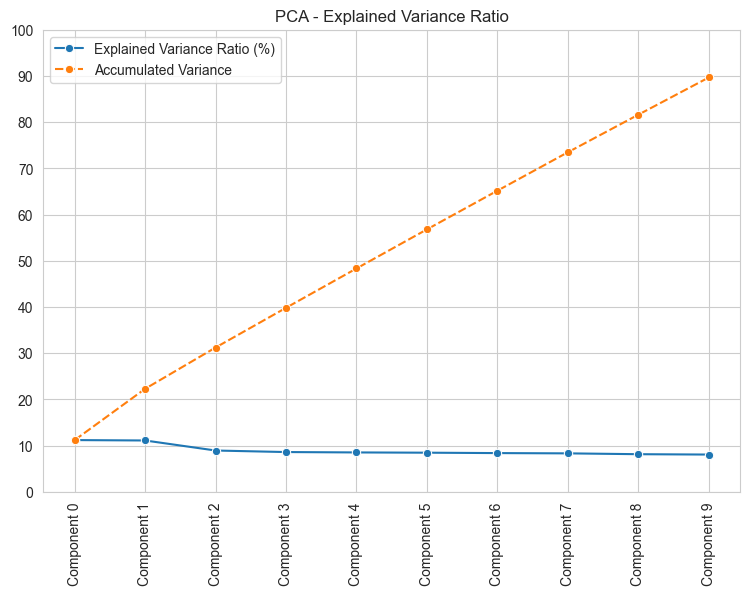

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

n_components = 10


def pca_components_analysis(df_pca, n_components):
    pca = PCA(n_components=n_components).fit(df_pca)
    x_PCA = pca.transform(df_pca)

    ComponentsList = ["Component " + str(number)
                      for number in range(n_components)]
    dfExplVarRatio = pd.DataFrame(
        data=np.round(100 * pca.explained_variance_ratio_, 3),
        index=ComponentsList,
        columns=['Explained Variance Ratio (%)'])

    dfExplVarRatio['Accumulated Variance'] = dfExplVarRatio['Explained Variance Ratio (%)'].cumsum()

    PercentageOfDataExplained = dfExplVarRatio['Explained Variance Ratio (%)'].sum()

    print(dfExplVarRatio)
    print(f"\n* The {n_components} components explain {round(PercentageOfDataExplained, 2)}% of the data \n")

    plt.figure(figsize=(9, 6))
    sns.lineplot(data=dfExplVarRatio, marker="o")
    plt.xticks(rotation=90)
    plt.yticks(np.arange(0, 110, 10))
    plt.title("PCA - Explained Variance Ratio")
    plt.show()


pca_components_analysis(df_pca=df_pca, n_components=n_components)

Based on the PCA analysis, we select the optimal number of components where the explained variance ratio starts to plateau. Update the `n_components` parameter in `PipelineCluster()` above if needed, then rerun from the next cell.

             Explained Variance Ratio (%)  Accumulated Variance
Component 0                        11.190                11.190
Component 1                        11.102                22.292
Component 2                         8.930                31.222
Component 3                         8.598                39.820
Component 4                         8.516                48.336
Component 5                         8.460                56.796

* The 6 components explain 56.8% of the data 



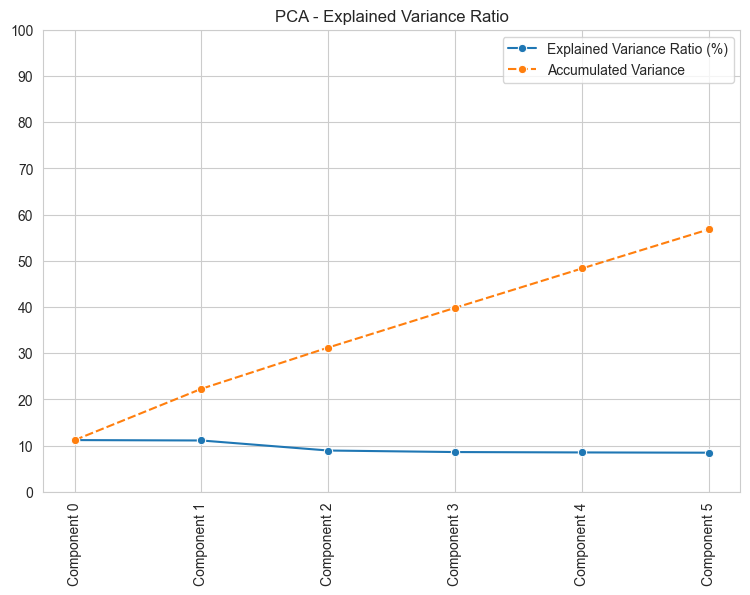

In [12]:
pca_components_analysis(df_pca=df_pca, n_components=6)

Update `PipelineCluster()` with the chosen number of PCA components

In [13]:
def PipelineCluster():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        ("scaler", StandardScaler()),

        ("PCA", PCA(n_components=6, random_state=0)),

        ("model", KMeans(n_clusters=10, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


In [14]:
pipeline_cluster = PipelineCluster()

# Everything except KMeans
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df)

print(df_analysis.shape, '\n', type(df_analysis))

(14701, 6) 
 <class 'numpy.ndarray'>


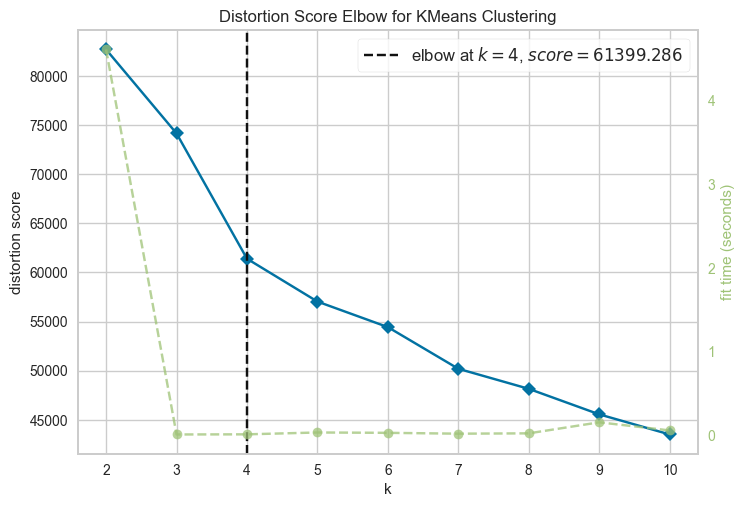

In [15]:
from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(KMeans(random_state=0), k=(2, 11), force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()

=== Average Silhouette Score for different number of clusters ===


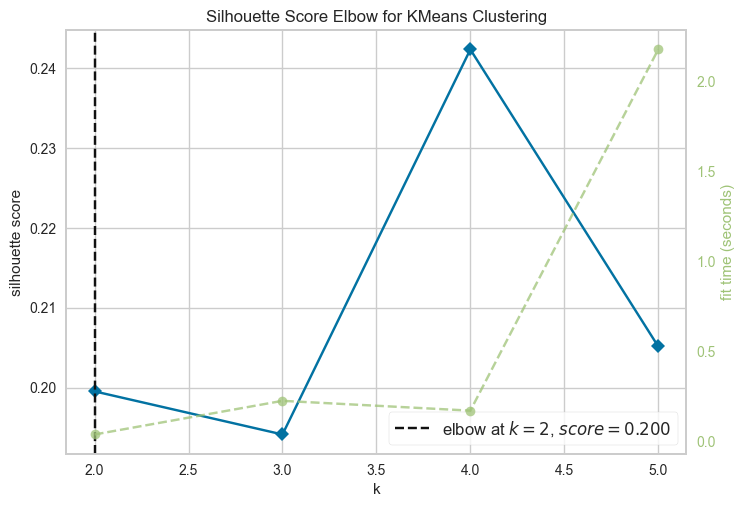



=== Silhouette plot for 2 clusters ===


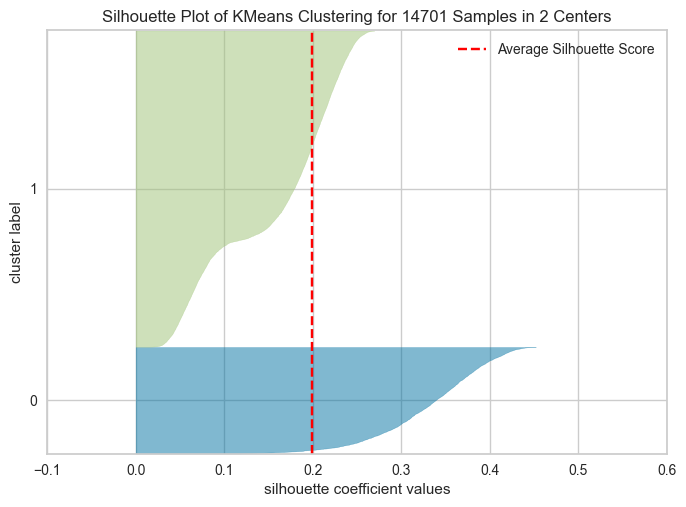



=== Silhouette plot for 3 clusters ===


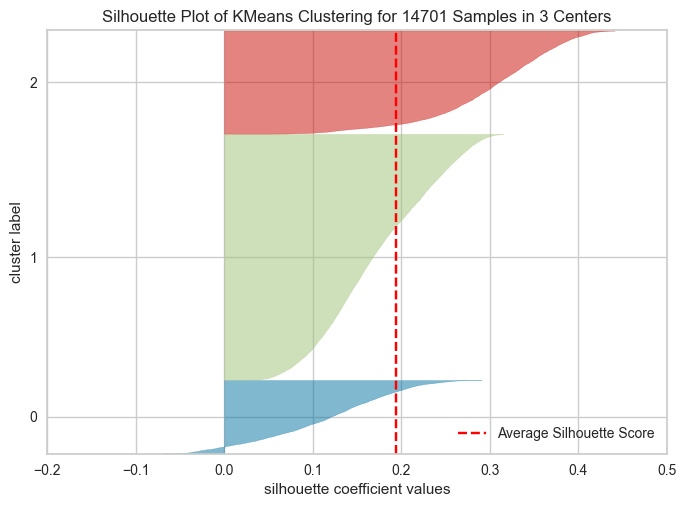



=== Silhouette plot for 4 clusters ===


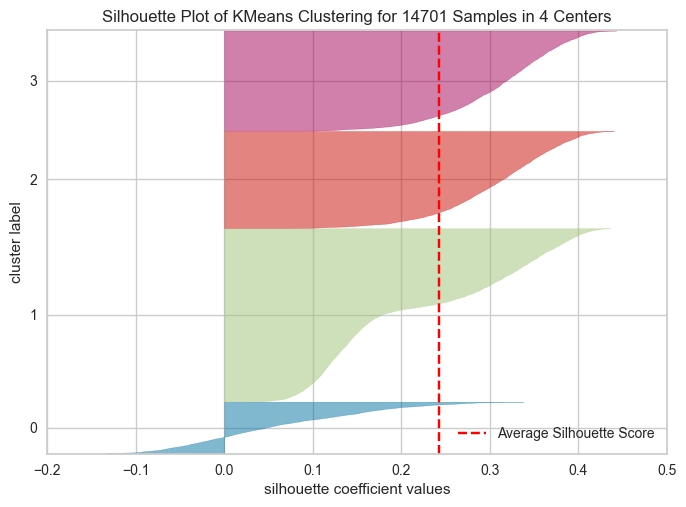



=== Silhouette plot for 5 clusters ===


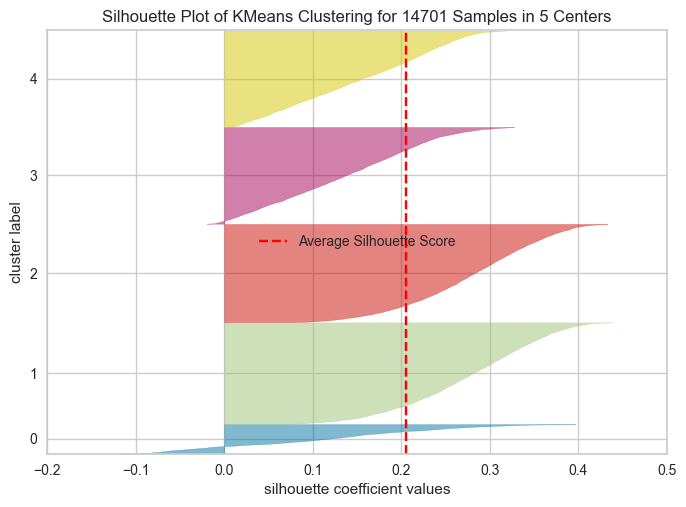

In [16]:
from yellowbrick.cluster import SilhouetteVisualizer

n_cluster_start, n_cluster_stop = 2, 6

print("=== Average Silhouette Score for different number of clusters ===")
visualizer = KElbowVisualizer(
    KMeans(random_state=0), k=(n_cluster_start, n_cluster_stop),
    metric='silhouette', force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()
print("\n")

for n_clusters in np.arange(start=n_cluster_start, stop=n_cluster_stop):
    print(f"=== Silhouette plot for {n_clusters} clusters ===")
    visualizer = SilhouetteVisualizer(
        KMeans(n_clusters=n_clusters, random_state=0),
        colors='yellowbrick', force_model=True)
    visualizer.fit(df_analysis)
    visualizer.show()
    plt.show()
    print("\n")

In [17]:
def PipelineCluster():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        ("scaler", StandardScaler()),

        ("PCA", PCA(n_components=6, random_state=0)),

        ("model", KMeans(n_clusters=3, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


Based on the elbow and silhouette analysis, we select the best number of clusters. Update `n_clusters` in `PipelineCluster()` if needed.

## Fit Cluster Pipeline

Quick recap of our data for training the cluster pipeline

In [18]:
X = df.copy()
print(X.shape)
X.head(3)

(14701, 11)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9


Fit cluster pipeline

In [19]:
pipeline_cluster = PipelineCluster()
pipeline_cluster.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Add cluster predictions to dataset

We add a column `Clusters` (with the cluster pipeline predictions) to the dataset

In [20]:
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)

(14701, 12)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,1
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9,1


* Clusters frequencies 
          proportion
Clusters            
1               0.58
2               0.24
0               0.17 




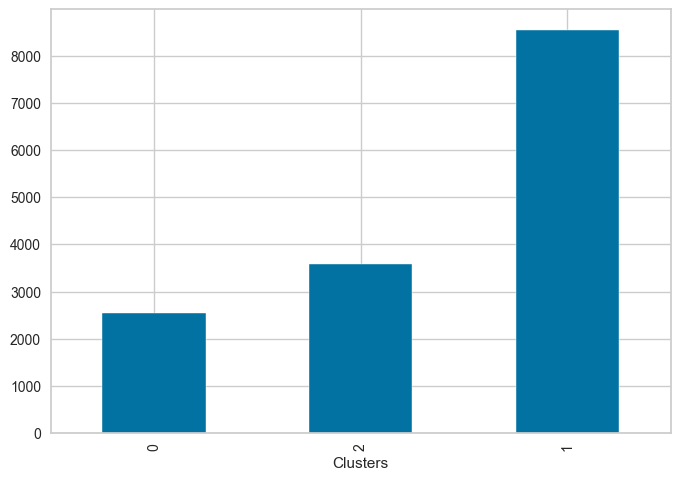

In [21]:
print(f"* Clusters frequencies \n{
    X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.show()

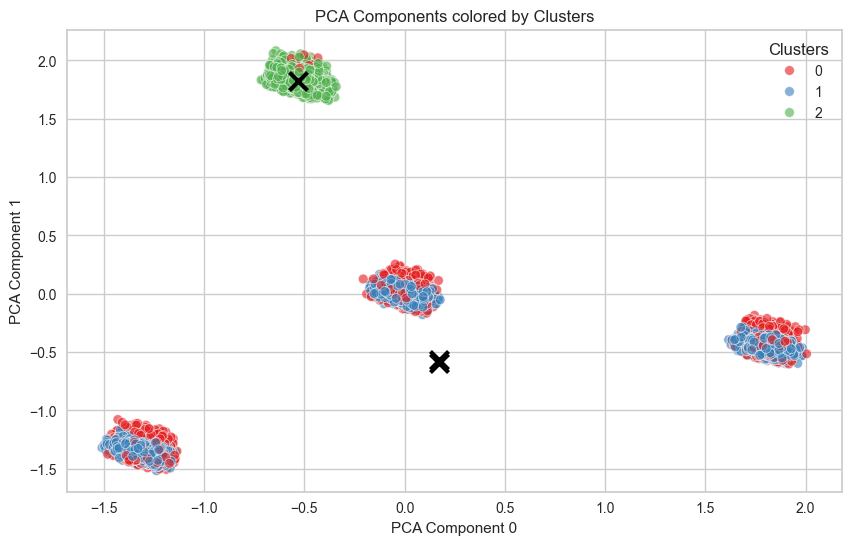

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_analysis[:, 0], y=df_analysis[:, 1],
                hue=X['Clusters'], palette='Set1', alpha=0.6)
plt.scatter(x=pipeline_cluster['model'].cluster_centers_[:, 0], y=pipeline_cluster['model'].cluster_centers_[:, 1],
            marker="x", s=169, linewidths=3, color="black")
plt.xlabel("PCA Component 0")
plt.ylabel("PCA Component 1")
plt.title("PCA Components colored by Clusters")
plt.show()

We save the cluster predictions from this pipeline to use for comparison later.

In [23]:
cluster_predictions_with_all_variables = X['Clusters']
cluster_predictions_with_all_variables

0        1
1        0
2        1
3        2
4        1
        ..
14696    1
14697    1
14698    1
14699    1
14700    0
Name: Clusters, Length: 14701, dtype: int32

---

## Fit a classifier to explain clusters

We train a GradientBoostingClassifier where the target is the cluster label and the features are the original variables. This lets us identify which features best define each cluster.

We copy X to a DataFrame `df_clf`

In [24]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(14701, 12)


,job_title,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,PT,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,1
1,Principal Data Scientist,EX,PT,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,0
2,Research Scientist,SE,CT,Singapore,S,Singapore,100,Associate,6,Energy,7.9,1


Split Train and Test sets

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_clf.drop(['Clusters'], axis=1),
    df_clf['Clusters'],
    test_size=0.2,
    random_state=0
)

print(X_train.shape, X_test.shape)

(11760, 11) (2941, 11)


Create classifier pipeline

In [26]:
# ML algorithm
from sklearn.ensemble import GradientBoostingClassifier


def PipelineClf2ExplainClusters():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("OneHotEncoder", OneHotEncoder(
            variables=['employment_type'],
            drop_last=True)),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=['job_title', 'company_location', 'employee_residence', 'industry'])),

        ("SmartCorrelatedSelection", SmartCorrelatedSelection(
            variables=None, method="spearman",
            threshold=0.8, selection_method="variance")),

        ("scaler", StandardScaler()),

        ("model", GradientBoostingClassifier(random_state=0)),
    ])
    return pipeline_base


PipelineClf2ExplainClusters()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


Fit the classifier to the training data

In [27]:
pipeline_clf_cluster = PipelineClf2ExplainClusters()
pipeline_clf_cluster.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('OneHotEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,['employment_type']
,ignore_format,False
,encoding_method,'frequency'


## Evaluate classifier performance on Train and Test Sets

In [28]:
from sklearn.metrics import classification_report

print("--- Train Set ---")
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

print("--- Test Set ---")
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

--- Train Set ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2032
           1       0.99      1.00      0.99      6873
           2       1.00      1.00      1.00      2855

    accuracy                           0.99     11760
   macro avg       0.99      0.99      0.99     11760
weighted avg       0.99      0.99      0.99     11760

--- Test Set ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       523
           1       0.99      0.99      0.99      1684
           2       1.00      1.00      1.00       734

    accuracy                           0.99      2941
   macro avg       0.99      0.98      0.99      2941
weighted avg       0.99      0.99      0.99      2941



## Assess the most important features that define a cluster

* Best features to define a cluster: ['employment_type_FT', 'employee_residence']


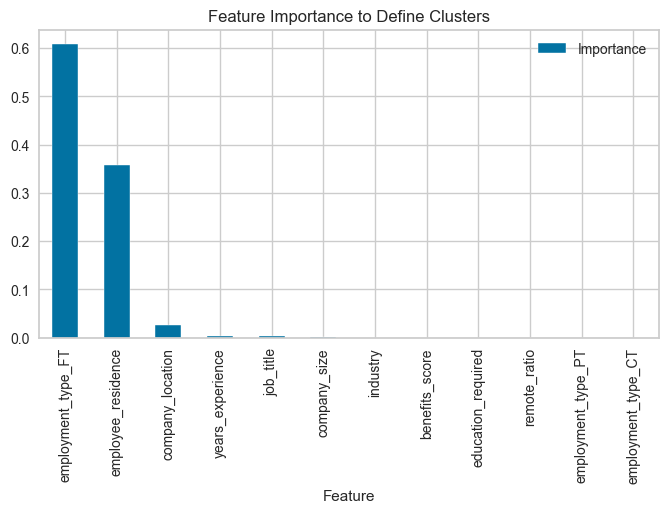

In [29]:
# after data cleaning and feature engineering, the feature space changes
# how many data cleaning and feature engineering steps does your pipeline have?
data_cleaning_feat_eng_steps = 4  # OrdinalMapping, OneHot, Frequency, SmartCorrelated
columns_after_data_cleaning_feat_eng = (
    Pipeline(pipeline_clf_cluster.steps[:data_cleaning_feat_eng_steps])
    .transform(X_train)
    .columns
)

best_features = columns_after_data_cleaning_feat_eng.to_list()


# create DataFrame to display feature importance
df_feature_importance = (
    pd.DataFrame(data={
        'Feature': best_features,
        'Importance': pipeline_clf_cluster['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Keep only features with above-average importance
mean_importance = df_feature_importance['Importance'].mean()
best_features = df_feature_importance[
    df_feature_importance['Importance'] >= mean_importance
]['Feature'].to_list()

print(f"* Best features to define a cluster: {best_features}")
df_feature_importance.plot(kind='bar', x='Feature', y='Importance', figsize=(8, 4))
plt.title("Feature Importance to Define Clusters")
plt.show()

We will store the `best_features` to use at a later stage.

In [30]:
best_features_pipeline_all_variables = best_features
best_features_pipeline_all_variables

['employment_type_FT', 'employee_residence']

---

# Cluster Analysis

Load function that plots a table with description for all Clusters

In [31]:
def DescriptionAllClusters(df, decimal_points=3):

    DescriptionAllClusters = pd.DataFrame(
        columns=df.drop(['Clusters'], axis=1).columns)
    for cluster in df.sort_values(by='Clusters')['Clusters'].unique():

        EDA_ClusterSubset = df.query(
            f"Clusters == {cluster}").drop(['Clusters'], axis=1)
        ClusterDescription = Clusters_IndividualDescription(
            EDA_ClusterSubset, cluster, decimal_points)
        DescriptionAllClusters = pd.concat(
            [DescriptionAllClusters, ClusterDescription], axis=0)

    return DescriptionAllClusters


def Clusters_IndividualDescription(EDA_ClusterSubset, cluster, decimal_points):
    ClusterDescription = pd.DataFrame()

    for column in EDA_ClusterSubset.columns:
        if EDA_ClusterSubset[column].dtype == 'object':
            ClusterDescription[column] = (
                EDA_ClusterSubset[column]
                .value_counts(normalize=True)
                .head(3)
                .apply(lambda x: f"{100*x:.{decimal_points}f}%")
                .reset_index()
                .apply(lambda row: f"'{row.iloc[0]}': {row.iloc[1]} ", axis=1)
                .str.cat(sep=', ')
            )
            ClusterDescription[column] = [ClusterDescription[column].values[0]]
        else:
            ClusterDescription[column] = (
                f"{EDA_ClusterSubset[column].quantile(0.25).round(decimal_points)}"
                f" -- {EDA_ClusterSubset[column].quantile(0.75).round(decimal_points)}"
            )

    ClusterDescription.insert(loc=0, column='Cluster', value=cluster)

    return ClusterDescription

Load a custom function to plot cluster distribution per variable (absolute and relative levels)

In [32]:
import plotly.express as px


def cluster_distribution_per_variable(df, target):
    """
    The data should have 2 variables: the cluster predictions and
    the variable you want to analyse. We use plotly express to create 2 plots:
    Cluster distribution across the target.
    Relative presence of the target level in each cluster.
    """
    df_bar_plot = df.groupby(['Clusters', target]).size().reset_index(name='Count')
    df_bar_plot.columns = ['Clusters', target, 'Count']
    df_bar_plot[target] = df_bar_plot[target].astype('object')

    print(f"\n* Clusters distribution across {target} levels")
    fig = px.bar(df_bar_plot, x='Clusters', y='Count',
                 color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.show()

    df_relative = (
        df
        .groupby(['Clusters', target]).size()
        .unstack(fill_value=0)
        .apply(lambda x: 100 * x / x.sum(), axis=1)
        .stack()
        .reset_index(name='Relative Percentage (%)')
        .sort_values(by=['Clusters', target])
    )
    df_relative.columns = ['Clusters', target, 'Relative Percentage (%)']

    print(f"\n* Relative Percentage (%) of {target} in each cluster")
    fig = px.line(df_relative, x='Clusters', y='Relative Percentage (%)',
                  color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.update_traces(mode='markers+lines')
    fig.show()

Create a DataFrame that contains best features and Clusters Predictions since we want to analyse the patterns for each cluster.

In [33]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(
    items=best_features + ['Clusters'], axis=1)
print(df_cluster_profile.shape)
df_cluster_profile.head(3)

(14701, 2)


,employee_residence,Clusters
0,United Kingdom,1
1,Argentina,0
2,Singapore,1


We also want to analyse **SalaryBand** levels (Low / Mid / High) derived from `salary_usd`.

In [34]:
df_salary = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")[['salary_usd']],
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")[['salary_usd']]
], ignore_index=True)

q33, q67 = df_salary['salary_usd'].quantile([0.33, 0.67])
df_salary['SalaryBand'] = pd.cut(
    df_salary['salary_usd'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Mid', 'High']
).astype('object')

df_salary = df_salary.drop(columns=['salary_usd'])
df_salary.head(3)

,SalaryBand
0,High
1,High
2,Mid


## Cluster profile based on the best features

In [35]:
def DescriptionAllClusters(df, decimal_points=3):

    DescriptionAllClusters = pd.DataFrame(
        columns=df.drop(['Clusters'], axis=1).columns)
    for cluster in df.sort_values(by='Clusters')['Clusters'].unique():

        EDA_ClusterSubset = df.query(
            f"Clusters == {cluster}").drop(['Clusters'], axis=1)
        ClusterDescription = Clusters_IndividualDescription(
            EDA_ClusterSubset, cluster, decimal_points)
        DescriptionAllClusters = pd.concat(
            [DescriptionAllClusters, ClusterDescription], axis=0)

    return DescriptionAllClusters


def Clusters_IndividualDescription(EDA_ClusterSubset, cluster, decimal_points):
    ClusterDescription = pd.DataFrame()

    for column in EDA_ClusterSubset.columns:
        if EDA_ClusterSubset[column].dtype == 'object':
            description = (
                EDA_ClusterSubset[column]
                .value_counts(normalize=True)
                .head(3)
                .apply(lambda x: f"{100*x:.{decimal_points}f}%")
                .reset_index()
                .apply(lambda row: f"'{row.iloc[0]}': {row.iloc[1]} ", axis=1)
                .str.cat(sep=', ')
            )
            ClusterDescription[column] = [description if description else 'N/A']
        else:
            ClusterDescription[column] = [
                f"{EDA_ClusterSubset[column].quantile(0.25).round(decimal_points)}"
                f" -- {EDA_ClusterSubset[column].quantile(0.75).round(decimal_points)}"
            ]

    ClusterDescription.insert(loc=0, column='Cluster', value=cluster)

    return ClusterDescription

In [36]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(
    df=pd.concat([df_cluster_profile, df_salary], axis=1),
    decimal_points=0)
clusters_profile

,employee_residence,SalaryBand,Cluster
0,"'India': 13% , 'Romania': 3% , 'Argentina': 3%","'Low': 40% , 'High': 31% , 'Mid': 29%",0.0
0,"'Singapore': 6% , 'France': 6% , 'Ireland': 6%","'Mid': 36% , 'High': 33% , 'Low': 31%",1.0
0,"'Israel': 5% , 'China': 5% , 'Ireland': 4%","'High': 34% , 'Low': 34% , 'Mid': 33%",2.0


## Clusters distribution across SalaryBand levels & Relative Percentage of SalaryBand in each cluster

In [37]:
df_cluster_vs_salary = df_salary.copy()
df_cluster_vs_salary['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs_salary, target='SalaryBand')


* Clusters distribution across SalaryBand levels



* Relative Percentage (%) of SalaryBand in each cluster


---

# Fit New Cluster Pipeline with most important features

In order to reduce the feature space, we will study the trade-off between the previous Cluster Pipeline (fitted with all variables) and a Pipeline using only the variables that are most important to define the clusters.

To evaluate this trade-off we will:

1. Conduct an elbow method and silhouette analysis and check if the same number of clusters is suggested.
2. Fit a new cluster pipeline and compare if the predictions from this pipeline are "equivalent" to the predictions from the previous pipeline.
3. Fit a classifier to explain clusters, and check if performance on Train and Test sets is similar to the previous pipeline.
4. Check if the most important features and cluster profiles are similar.

In [38]:
best_features_pipeline_all_variables

['employment_type_FT', 'employee_residence']

## Subset data with the most relevant variables

In [39]:
df_reduced = df.filter(best_features_pipeline_all_variables)
df_reduced.head(3)

,employee_residence
0,United Kingdom
1,Argentina
2,Singapore


Detect which best features are categorical vs numerical, so we can build the reduced pipeline correctly.

In [40]:
# Ordinal best features (those with known order)
ordinal_vars_map = {
    'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
    'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
    'company_size': {'S': 0, 'M': 1, 'L': 2},
}

ordinal_best_feats = {k: v for k, v in ordinal_vars_map.items()
                      if k in best_features_pipeline_all_variables}

# One-hot best features
onehot_best_feats = [f for f in ['employment_type']
                     if f in best_features_pipeline_all_variables]

# Frequency-encoded best features
freq_best_feats = [f for f in ['job_title', 'company_location', 'employee_residence', 'industry']
                   if f in best_features_pipeline_all_variables]

print("Ordinal best features:", list(ordinal_best_feats.keys()))
print("One-hot best features:", onehot_best_feats)
print("Frequency best features:", freq_best_feats)

Ordinal best features: []
One-hot best features: []
Frequency best features: ['employee_residence']


## Rewrite Cluster Pipeline

We update the pipeline, considering only the most important variables. Since we already know which features to use, we don't need SmartCorrelatedSelection or PCA.

In [41]:
def PipelineCluster():
    steps = []

    if ordinal_best_feats:
        steps.append(("OrdinalMappingEncoder",
                       OrdinalMappingEncoder(mappings=ordinal_best_feats)))

    if onehot_best_feats:
        steps.append(("OneHotEncoder",
                       OneHotEncoder(variables=onehot_best_feats, drop_last=True)))

    if freq_best_feats:
        steps.append(("FrequencyEncoder",
                       CountFrequencyEncoder(encoding_method='frequency',
                                             variables=freq_best_feats)))

    steps.append(("scaler", StandardScaler()))
    steps.append(("model", KMeans(n_clusters=3, random_state=0)))

    return Pipeline(steps)


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FrequencyEncoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'frequency'
,variables,['employee_residence']
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


## Apply Elbow Method and Silhouette analysis

In [42]:
pipeline_cluster = PipelineCluster()
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df_reduced)

print(df_analysis.shape, '\n', type(df_analysis))

(14701, 1) 
 <class 'numpy.ndarray'>


Elbow Analysis

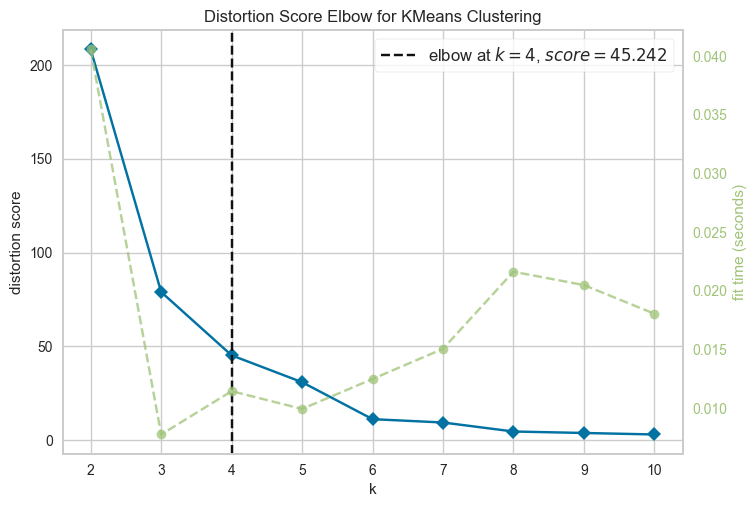

In [43]:
visualizer = KElbowVisualizer(KMeans(random_state=0), k=(2, 11), force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()

=== Average Silhouette Score for different number of clusters ===


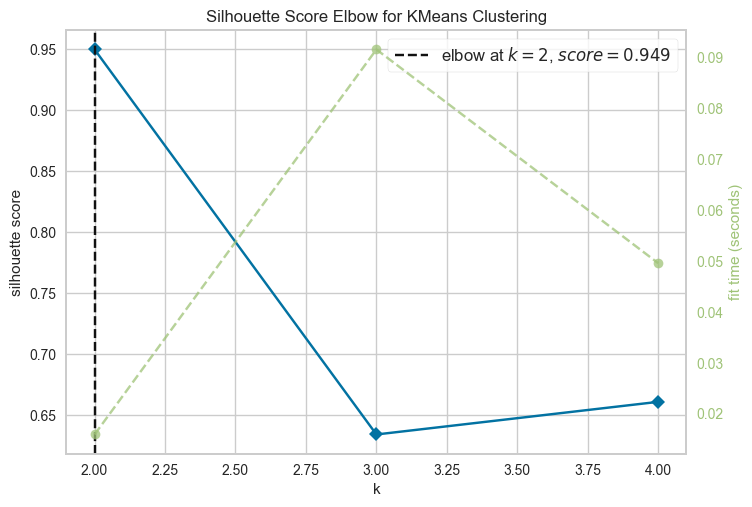



=== Silhouette plot for 2 clusters ===


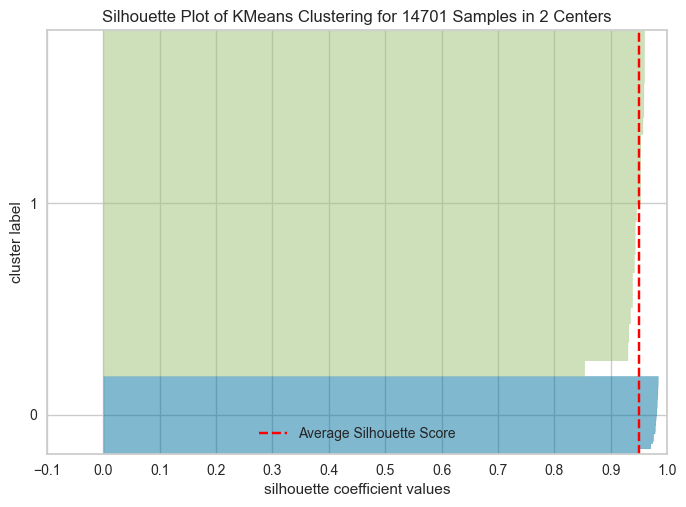



=== Silhouette plot for 3 clusters ===


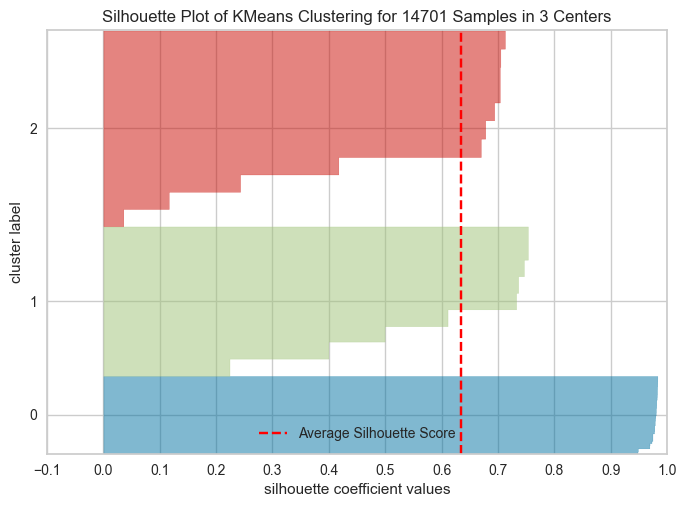



=== Silhouette plot for 4 clusters ===


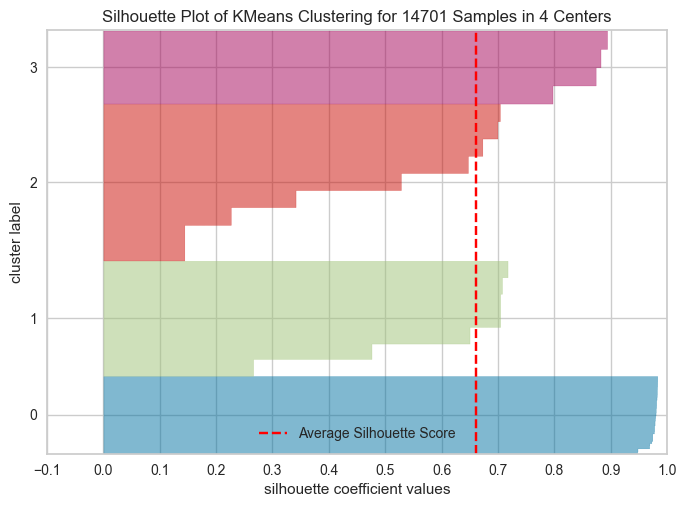

In [44]:
n_cluster_start, n_cluster_stop = 2, 5

print("=== Average Silhouette Score for different number of clusters ===")
visualizer = KElbowVisualizer(
    KMeans(random_state=0), k=(n_cluster_start, n_cluster_stop),
    metric='silhouette', force_model=True)
visualizer.fit(df_analysis)
visualizer.show()
plt.show()
print("\n")

for n_clusters in np.arange(start=n_cluster_start, stop=n_cluster_stop):
    print(f"=== Silhouette plot for {n_clusters} clusters ===")
    visualizer = SilhouetteVisualizer(
        KMeans(n_clusters=n_clusters, random_state=0),
        colors='yellowbrick', force_model=True)
    visualizer.fit(df_analysis)
    visualizer.show()
    plt.show()
    print("\n")

## Fit New Cluster Pipeline

We set X as our training set for the cluster. It is a copy of `df_reduced`.

In [45]:
X = df_reduced.copy()
print(X.shape)
X.head(3)

(14701, 1)


,employee_residence
0,United Kingdom
1,Argentina
2,Singapore


Fit cluster pipeline

In [46]:
pipeline_cluster = PipelineCluster()
pipeline_cluster.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FrequencyEncoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'frequency'
,variables,['employee_residence']
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


## Add cluster predictions to dataset

We add a column `Clusters` (with the cluster pipeline predictions) to the dataset

In [47]:
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)

(14701, 2)


,employee_residence,Clusters
0,United Kingdom,2
1,Argentina,0
2,Singapore,2


* Clusters frequencies 
          proportion
Clusters            
2               0.46
1               0.35
0               0.18 




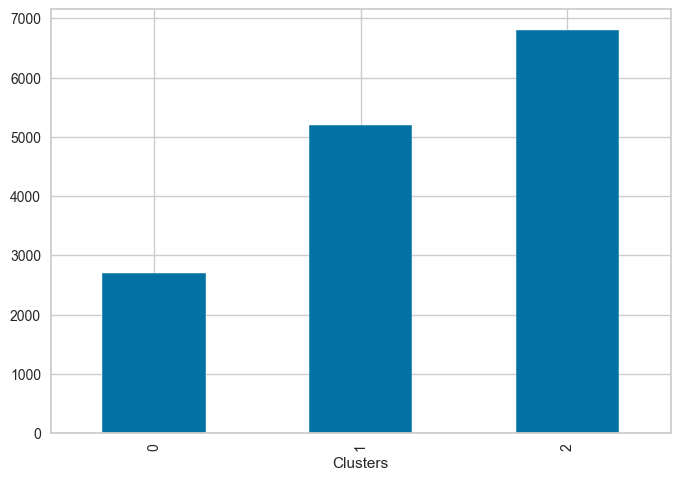

In [48]:
print(f"* Clusters frequencies \n{
    X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.show()

## Compare current cluster predictions to previous cluster predictions

We just fitted a new cluster pipeline and want to compare if its predictions are "equivalent" to the previous cluster.

These are the predictions from the previous cluster pipeline â€” trained with all variables:

In [49]:
cluster_predictions_with_all_variables

0        1
1        0
2        1
3        2
4        1
        ..
14696    1
14697    1
14698    1
14699    1
14700    0
Name: Clusters, Length: 14701, dtype: int32

And these are the predictions from the current cluster pipeline (trained with the best features):

In [50]:
cluster_predictions_with_best_features = X['Clusters']
cluster_predictions_with_best_features

0        2
1        0
2        2
3        1
4        2
        ..
14696    1
14697    2
14698    2
14699    2
14700    1
Name: Clusters, Length: 14701, dtype: int32

We use a confusion matrix to evaluate if the predictions of both pipelines are "equivalent"

In [51]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(
    cluster_predictions_with_all_variables,
    cluster_predictions_with_best_features))

[[1997  514   44]
 [  71 3421 5065]
 [ 627 1261 1701]]


## Fit a classifier to explain the reduced-feature clusters

In [52]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(14701, 2)


,employee_residence,Clusters
0,United Kingdom,2
1,Argentina,0
2,Singapore,2


Split Train and Test sets

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clf.drop(['Clusters'], axis=1),
    df_clf['Clusters'],
    test_size=0.2,
    random_state=0
)

print(X_train.shape, X_test.shape)

(11760, 1) (2941, 1)


Rewrite pipeline to explain clusters

In [54]:
def PipelineClf2ExplainClusters():
    steps = []

    if ordinal_best_feats:
        steps.append(("OrdinalMappingEncoder",
                       OrdinalMappingEncoder(mappings=ordinal_best_feats)))

    if onehot_best_feats:
        steps.append(("OneHotEncoder",
                       OneHotEncoder(variables=onehot_best_feats, drop_last=True)))

    if freq_best_feats:
        steps.append(("FrequencyEncoder",
                       CountFrequencyEncoder(encoding_method='frequency',
                                             variables=freq_best_feats)))

    steps.append(("scaler", StandardScaler()))
    steps.append(("model", GradientBoostingClassifier(random_state=0)))

    return Pipeline(steps)


PipelineClf2ExplainClusters()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FrequencyEncoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'frequency'
,variables,['employee_residence']
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


Fit the classifier

In [55]:
pipeline_clf_cluster = PipelineClf2ExplainClusters()
pipeline_clf_cluster.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FrequencyEncoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'frequency'
,variables,['employee_residence']
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


## Evaluate classifier performance on Train and Test Sets

In [56]:
print("--- Train Set ---")
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

print("--- Test Set ---")
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

--- Train Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2156
           1       1.00      1.00      1.00      4142
           2       1.00      1.00      1.00      5462

    accuracy                           1.00     11760
   macro avg       1.00      1.00      1.00     11760
weighted avg       1.00      1.00      1.00     11760

--- Test Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       539
           1       1.00      1.00      1.00      1054
           2       1.00      1.00      1.00      1348

    accuracy                           1.00      2941
   macro avg       1.00      1.00      1.00      2941
weighted avg       1.00      1.00      1.00      2941



## Assess Most Important Features

* Most important features (ordered): ['employee_residence']


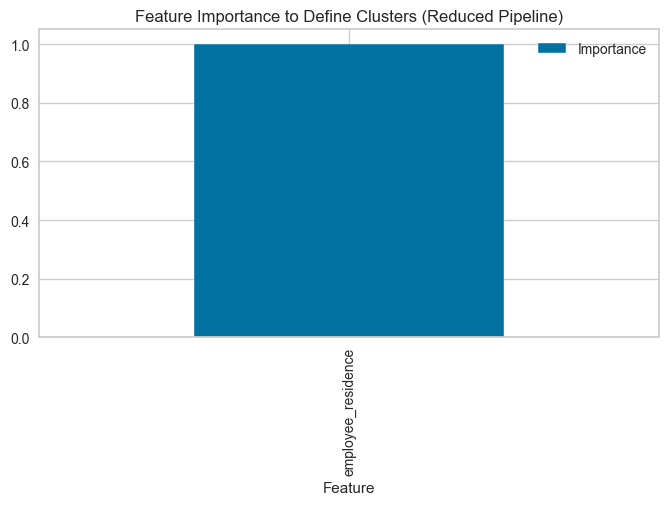

In [57]:
# since we don't have feature selection step in this pipeline,
# best_features is X_train columns
best_features = X_train.columns.to_list()

# create a DataFrame to display feature importance
df_feature_importance = (
    pd.DataFrame(data={
        'Feature': best_features,
        'Importance': pipeline_clf_cluster['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

best_features = df_feature_importance['Feature'].to_list()

print(f"* Most important features (ordered): {best_features}")
df_feature_importance.plot(kind='bar', x='Feature', y='Importance', figsize=(8, 4))
plt.title("Feature Importance to Define Clusters (Reduced Pipeline)")
plt.show()

---

# Cluster Analysis (Reduced Pipeline)

Create a DataFrame that contains the best features and Clusters Predictions: we want to analyse the patterns for each cluster.

In [58]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(
    items=best_features + ['Clusters'], axis=1)
df_cluster_profile.head(3)

,employee_residence,Clusters
0,United Kingdom,2
1,Argentina,0
2,Singapore,2


We also want to analyse SalaryBand levels

In [59]:
df_salary = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")[['salary_usd']],
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")[['salary_usd']]
], ignore_index=True)

q33, q67 = df_salary['salary_usd'].quantile([0.33, 0.67])
df_salary['SalaryBand'] = pd.cut(
    df_salary['salary_usd'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Mid', 'High']
).astype('object')

df_salary = df_salary.drop(columns=['salary_usd'])
df_salary.head(3)

,SalaryBand
0,High
1,High
2,Mid


## Cluster profile on most important features

In [60]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(
    df=pd.concat([df_cluster_profile, df_salary], axis=1),
    decimal_points=0)
clusters_profile

,employee_residence,SalaryBand,Cluster
0,"'Romania': 4% , 'Argentina': 4% , 'Vietnam': 4%","'Mid': 34% , 'Low': 33% , 'High': 32%",0.0
0,"'Germany': 11% , 'Netherlands': 11% , 'Austria': 11%","'Low': 34% , 'Mid': 33% , 'High': 33%",1.0
0,"'Ireland': 9% , 'Canada': 9% , 'France': 9%","'Mid': 35% , 'High': 33% , 'Low': 32%",2.0


## Clusters distribution across SalaryBand levels & Relative Percentage of SalaryBand in each cluster

In [61]:
df_cluster_vs_salary = df_salary.copy()
df_cluster_vs_salary['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs_salary, target='SalaryBand')


* Clusters distribution across SalaryBand levels



* Relative Percentage (%) of SalaryBand in each cluster


---

# Which pipeline should I deploy?

## Decision Criteria

To evaluate the trade-off we assessed the following criteria:

1. Conduct an elbow method and silhouette analysis and check if the same number of clusters is suggested.
2. Fit a new cluster pipeline and compare if the predictions from this pipeline are "equivalent" to the predictions from the previous pipeline.
3. Fit a classifier to explain clusters, and check if performance on Train and Test sets is similar to the previous pipeline.
4. Check if the most important features and cluster profiles are similar.

In [62]:
pipeline_cluster

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('FrequencyEncoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,encoding_method,'frequency'
,variables,['employee_residence']
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True


**Both pipelines show the same limitation.** The full-feature and reduced-feature KMeans pipelines produce
weak, overlapping clusters (silhouette ~ 0.53) dominated by binary flags rather than meaningful role
characteristics. The issue is not feature selection - it is fundamental to how the data is distributed.

Before concluding that the data lacks cluster structure, we explore **five fundamentally different
approaches** that vary in algorithm, feature representation, and philosophy.

---

## Method 1: Domain-Driven Segmentation

Instead of unsupervised clustering, we leverage the regression model's findings to create
**salary-based tiers** using quantiles. The regression model (R² = 0.86) showed that
`experience_level`, `company_location`, `employee_residence`, and `company_size` drive salary.
We use these insights to create interpretable segments.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
sns.set_style("whitegrid")

# Reload full data with salary
df_full = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv"),
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")
], ignore_index=True)

# Create salary tiers using quantiles
df_full['SalaryTier'] = pd.qcut(
    df_full['salary_usd'], q=4,
    labels=['Entry', 'Mid', 'Senior', 'Executive']
)

print("=== Salary Tier Distribution ===")
print(df_full['SalaryTier'].value_counts(normalize=True).round(3))
print()

# Profile each tier
profile_cols = ['experience_level', 'company_size', 'education_required',
                'remote_ratio', 'benefits_score', 'years_experience']
print("=== Tier Profiles (mean/mode) ===")
for tier in ['Entry', 'Mid', 'Senior', 'Executive']:
    subset = df_full[df_full['SalaryTier'] == tier]
    print(f"\n--- {tier} (n={len(subset)}) ---")
    for col in profile_cols:
        if df_full[col].dtype == 'object':
            print(f"  {col}: {subset[col].mode().iloc[0]}")
        else:
            print(f"  {col}: {subset[col].mean():.2f}")

=== Salary Tier Distribution ===
SalaryTier
Entry        0.25
Mid          0.25
Senior       0.25
Executive    0.25
Name: proportion, dtype: float64

=== Tier Profiles (mean/mode) ===

--- Entry (n=3676) ---
  experience_level: EN
  company_size: S
  education_required: PhD
  remote_ratio: 49.82
  benefits_score: 7.51
  years_experience: 2.20

--- Mid (n=3675) ---
  experience_level: MI
  company_size: S
  education_required: PhD
  remote_ratio: 50.41
  benefits_score: 7.49
  years_experience: 3.37

--- Senior (n=3675) ---
  experience_level: SE
  company_size: L
  education_required: Bachelor
  remote_ratio: 50.44
  benefits_score: 7.47
  years_experience: 6.98

--- Executive (n=3675) ---
  experience_level: EX
  company_size: L
  education_required: Bachelor
  remote_ratio: 50.01
  benefits_score: 7.51
  years_experience: 12.78


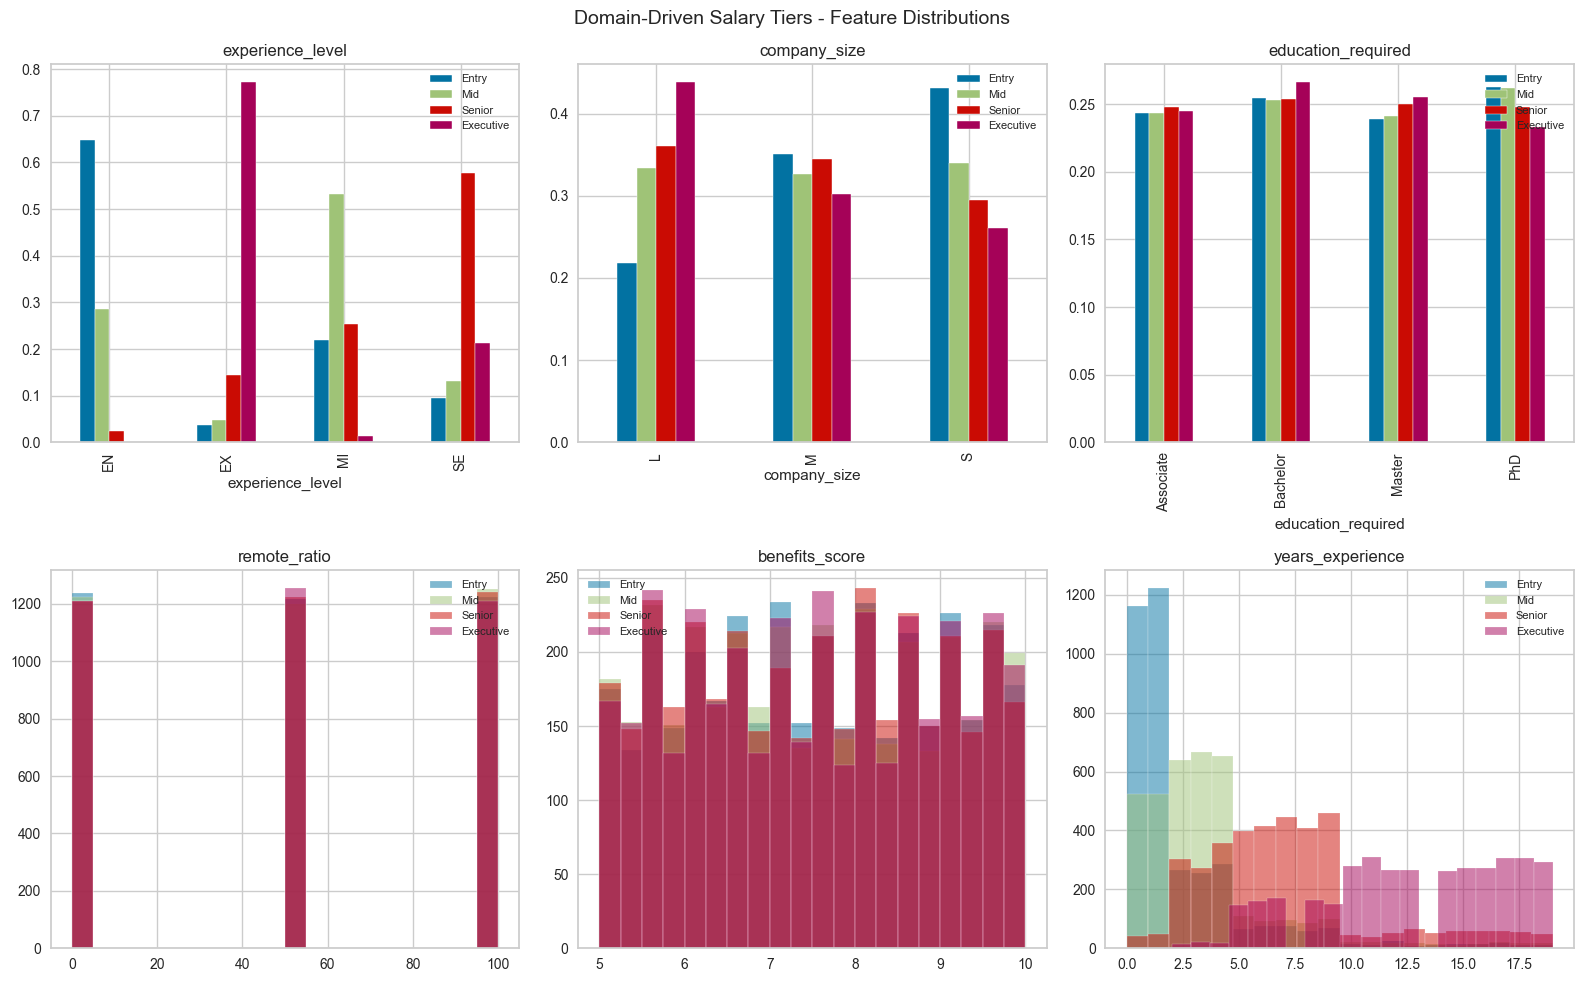


Conclusion: Domain-driven tiers give 4 balanced, interpretable segments
tied directly to salary outcomes.


In [64]:
# Visualise salary tiers across key features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Domain-Driven Salary Tiers - Feature Distributions", fontsize=14)

for ax, col in zip(axes.flatten(), profile_cols):
    if df_full[col].dtype == 'object':
        ct = pd.crosstab(df_full[col], df_full['SalaryTier'], normalize='columns')
        ct.plot(kind='bar', ax=ax, legend=False)
    else:
        for tier in ['Entry', 'Mid', 'Senior', 'Executive']:
            subset = df_full[df_full['SalaryTier'] == tier]
            ax.hist(subset[col], alpha=0.5, label=tier, bins=20)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nConclusion: Domain-driven tiers give 4 balanced, interpretable segments")
print("tied directly to salary outcomes.")

## Method 2: Cluster on Residuals

We use the trained regression model to predict salary, then cluster on the **residuals**
(prediction errors). This finds groups of people whose salary deviates from what the model
expects - revealing hidden patterns the regression couldn't capture.

In [65]:
# Define the custom FrequencyEncoder used when saving the pipeline in notebook 05
from sklearn.base import BaseEstimator, TransformerMixin


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Replaces categorical values with their frequency (fitted on train only)."""

    def __init__(self, variables):
        self.variables = variables

    def fit(self, X, y=None):
        self.freq_map_ = {
            col: X[col].value_counts(normalize=True).to_dict()
            for col in self.variables
        }
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.variables:
            X[col] = X[col].map(self.freq_map_[col]).fillna(0)
        return X


# Load the saved regression pipelines
pipeline_fe = joblib.load("outputs/ml_pipeline/predict_salary/v1/pipeline_data_cleaning_feat_eng.pkl")
pipeline_reg = joblib.load("outputs/ml_pipeline/predict_salary/v1/pipeline_regressor.pkl")

# Prepare features and predict
df_resid = df_full.copy()
X_all = df_resid.drop(['salary_usd', 'SalaryTier'], axis=1)
y_all = df_resid['salary_usd']

X_transformed = pipeline_fe.transform(X_all)
best_feats_reg = pd.read_csv("outputs/ml_pipeline/predict_salary/v1/X_train.csv").columns.tolist()
y_pred = pipeline_reg.predict(X_transformed[best_feats_reg])

# Compute residuals
df_resid['predicted_salary'] = y_pred
df_resid['residual'] = df_resid['salary_usd'] - df_resid['predicted_salary']
df_resid['abs_residual'] = df_resid['residual'].abs()
df_resid['pct_residual'] = df_resid['residual'] / df_resid['salary_usd'] * 100

print("=== Residual Statistics ===")
print(df_resid[['residual', 'abs_residual', 'pct_residual']].describe().round(2))

=== Residual Statistics ===
        residual  abs_residual  pct_residual
count   14701.00      14701.00      14701.00
mean     -171.43      15391.52         -2.49
std     21116.36      14457.35         17.06
min   -117508.28          0.20       -151.35
25%    -11469.06       5306.47        -13.02
50%        72.00      11298.69          0.08
75%     11187.26      19836.38         10.15
max    127736.28     127736.28         55.80


In [66]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Cluster on residual features
resid_features = df_resid[['residual', 'pct_residual']].copy()
scaler_resid = StandardScaler()
resid_scaled = scaler_resid.fit_transform(resid_features)

# Find best k
print("=== Silhouette Scores for Residual Clustering ===")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(resid_scaled)
    score = silhouette_score(resid_scaled, labels)
    print(f"  k={k}: silhouette = {score:.4f}")

# Fit with best k (typically 3: underpaid / fair / overpaid)
km_resid = KMeans(n_clusters=3, random_state=0, n_init=10)
df_resid['ResidualCluster'] = km_resid.fit_predict(resid_scaled)

print("\n=== Residual Cluster Distribution ===")
print(df_resid['ResidualCluster'].value_counts(normalize=True).round(3))

=== Silhouette Scores for Residual Clustering ===
  k=2: silhouette = 0.5289
  k=3: silhouette = 0.4558
  k=4: silhouette = 0.4997
  k=5: silhouette = 0.4816
  k=6: silhouette = 0.4864

=== Residual Cluster Distribution ===
ResidualCluster
2    0.441
0    0.365
1    0.194
Name: proportion, dtype: float64


=== Residual Cluster Profiles ===

Cluster 0 - Overpaid (n=5368)
  Mean residual:     $19,747
  Mean actual salary: $146,295
  Mean predicted:     $126,548
  Top experience_level: EX
  Top job_title:        AI Product Manager

Cluster 1 - Underpaid (n=2850)
  Mean residual:     $-28,613
  Mean actual salary: $112,964
  Mean predicted:     $141,577
  Top experience_level: EX
  Top job_title:        Computer Vision Engineer

Cluster 2 - Fair (n=6483)
  Mean residual:     $-4,161
  Mean actual salary: $102,780
  Mean predicted:     $106,941
  Top experience_level: MI
  Top job_title:        Machine Learning Engineer


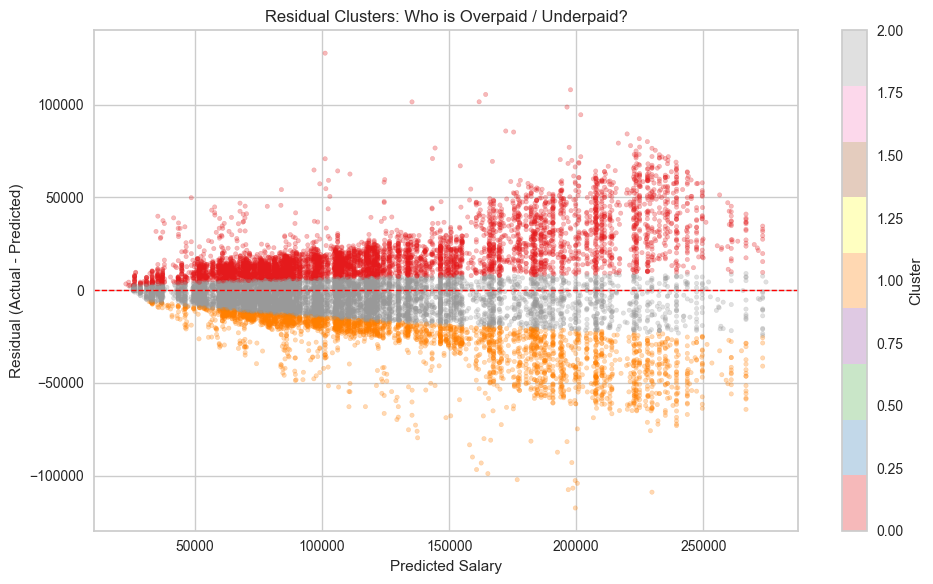

In [67]:
# Profile residual clusters
print("=== Residual Cluster Profiles ===")
for cl in sorted(df_resid['ResidualCluster'].unique()):
    subset = df_resid[df_resid['ResidualCluster'] == cl]
    avg_resid = subset['residual'].mean()
    label = "Overpaid" if avg_resid > 5000 else ("Underpaid" if avg_resid < -5000 else "Fair")
    print(f"\nCluster {cl} - {label} (n={len(subset)})")
    print(f"  Mean residual:     ${avg_resid:,.0f}")
    print(f"  Mean actual salary: ${subset['salary_usd'].mean():,.0f}")
    print(f"  Mean predicted:     ${subset['predicted_salary'].mean():,.0f}")
    print(f"  Top experience_level: {subset['experience_level'].mode().iloc[0]}")
    print(f"  Top job_title:        {subset['job_title'].mode().iloc[0]}")

# Scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_resid['predicted_salary'], df_resid['residual'],
                      c=df_resid['ResidualCluster'], cmap='Set1', alpha=0.3, s=10)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Salary")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Clusters: Who is Overpaid / Underpaid?")
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## Method 3: UMAP + HDBSCAN

**UMAP** preserves local structure better than PCA for mixed-type data.
**HDBSCAN** doesn't force every point into a cluster - it can label points as noise
if they don't belong to any natural group. This is more honest than KMeans.

In [68]:
import umap
import hdbscan

# Prepare data: use the same encoding as the cluster pipeline
# but without PCA - let UMAP handle dimensionality reduction
df_umap = df.copy()  # df without salary (from earlier in notebook)

# Encode manually (same as pipeline)
ordinal_maps = {
    'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
    'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
    'company_size': {'S': 0, 'M': 1, 'L': 2},
}
for col, mapping in ordinal_maps.items():
    df_umap[col] = df_umap[col].map(mapping)

# One-hot encode employment_type
df_umap = pd.get_dummies(df_umap, columns=['employment_type'], drop_first=True)

# Frequency encode high-cardinality categoricals
for col in ['job_title', 'company_location', 'employee_residence', 'industry']:
    freq = df_umap[col].value_counts(normalize=True)
    df_umap[col] = df_umap[col].map(freq)

# Scale
scaler_umap = StandardScaler()
X_umap_scaled = scaler_umap.fit_transform(df_umap)

print(f"Feature matrix shape: {X_umap_scaled.shape}")

c:\Users\chahi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



Feature matrix shape: (14701, 13)


In [69]:
# UMAP dimensionality reduction
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.0,
                    random_state=42, metric='euclidean')
embedding = reducer.fit_transform(X_umap_scaled)

print(f"UMAP embedding shape: {embedding.shape}")

# HDBSCAN clustering on the UMAP embedding
clusterer = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=50,
                             cluster_selection_method='eom')
hdb_labels = clusterer.fit_predict(embedding)

n_clusters_found = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
print(f"\nClusters found: {n_clusters_found}")
print(f"Noise points:   {n_noise} ({n_noise/len(hdb_labels)*100:.1f}%)")

if n_clusters_found > 1:
    mask = hdb_labels != -1
    score = silhouette_score(embedding[mask], hdb_labels[mask])
    print(f"Silhouette (excl. noise): {score:.4f}")

c:\Users\chahi\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP embedding shape: (14701, 2)

Clusters found: 9
Noise points:   0 (0.0%)
Silhouette (excl. noise): 0.8734


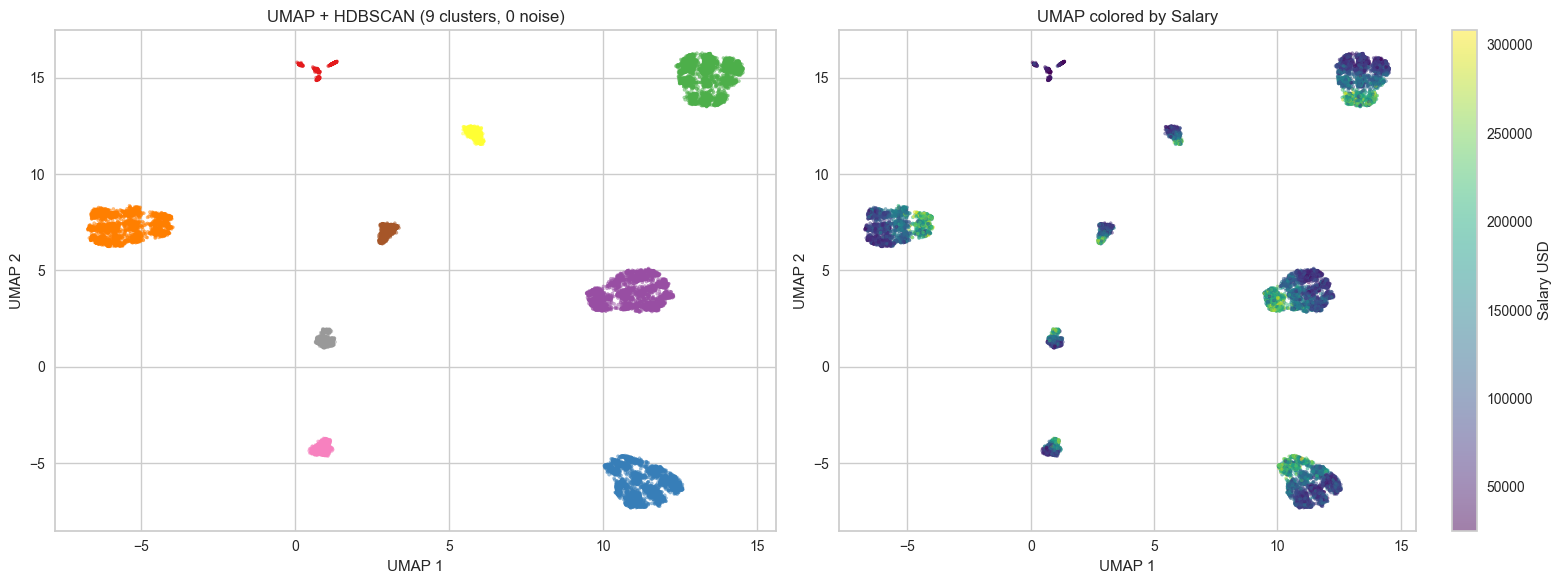


=== HDBSCAN Cluster Profiles ===

Cluster 0 (n=583)
  Mean salary:    $47,595
  Top job_title:  AI Specialist
  Top exp_level:  MI
  Mean benefits:  7.6

Cluster 1 (n=2887)
  Mean salary:    $123,641
  Top job_title:  Principal Data Scientist
  Top exp_level:  SE
  Mean benefits:  7.5

Cluster 2 (n=2835)
  Mean salary:    $124,872
  Top job_title:  Machine Learning Engineer
  Top exp_level:  EX
  Mean benefits:  7.5

Cluster 3 (n=2936)
  Mean salary:    $121,729
  Top job_title:  Machine Learning Engineer
  Top exp_level:  MI
  Mean benefits:  7.5

Cluster 4 (n=2862)
  Mean salary:    $125,301
  Top job_title:  Machine Learning Researcher
  Top exp_level:  EX
  Mean benefits:  7.5

Cluster 5 (n=629)
  Mean salary:    $121,290
  Top job_title:  Computer Vision Engineer
  Top exp_level:  EN
  Mean benefits:  7.4

Cluster 6 (n=679)
  Mean salary:    $123,914
  Top job_title:  Computer Vision Engineer
  Top exp_level:  EN
  Mean benefits:  7.4

Cluster 7 (n=663)
  Mean salary:    $122,024

In [70]:
# Visualise UMAP + HDBSCAN results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by HDBSCAN cluster
scatter1 = axes[0].scatter(embedding[:, 0], embedding[:, 1],
                           c=hdb_labels, cmap='Set1', s=5, alpha=0.5)
axes[0].set_title(f"UMAP + HDBSCAN ({n_clusters_found} clusters, {n_noise} noise)")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Right: colored by salary (for reference)
salary_vals = df_full['salary_usd'].values
scatter2 = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                           c=salary_vals, cmap='viridis', s=5, alpha=0.5)
axes[1].set_title("UMAP colored by Salary")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.colorbar(scatter2, ax=axes[1], label='Salary USD')

plt.tight_layout()
plt.show()

# Profile clusters if found
if n_clusters_found > 1:
    df_hdb = df_full.copy()
    df_hdb['HDB_Cluster'] = hdb_labels
    print("\n=== HDBSCAN Cluster Profiles ===")
    for cl in sorted(df_hdb[df_hdb['HDB_Cluster'] != -1]['HDB_Cluster'].unique()):
        subset = df_hdb[df_hdb['HDB_Cluster'] == cl]
        print(f"\nCluster {cl} (n={len(subset)})")
        print(f"  Mean salary:    ${subset['salary_usd'].mean():,.0f}")
        print(f"  Top job_title:  {subset['job_title'].mode().iloc[0]}")
        print(f"  Top exp_level:  {subset['experience_level'].mode().iloc[0]}")
        print(f"  Mean benefits:  {subset['benefits_score'].mean():.1f}")
else:
    print("\nHDBSCAN found no meaningful clusters - confirming the data lacks natural groupings.")

## Method 4: Feature Subspace Clustering

Instead of clustering all features at once (where binary flags dominate), we cluster on
**meaningful subsets** of features independently:
- **Seniority profile**: experience, education, benefits
- **Company profile**: location, size, remote ratio

In [71]:
# --- Subspace A: Seniority Profile ---
seniority_cols = ['experience_level', 'education_required', 'benefits_score', 'years_experience']
df_senior = df_full[seniority_cols].copy()

# Encode ordinals
df_senior['experience_level'] = df_senior['experience_level'].map(
    {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3})
df_senior['education_required'] = df_senior['education_required'].map(
    {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3})

scaler_s = StandardScaler()
X_senior = scaler_s.fit_transform(df_senior)

print("=== Seniority Subspace: Silhouette Scores ===")
best_k_s, best_score_s = 2, -1
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_senior)
    score = silhouette_score(X_senior, labels)
    print(f"  k={k}: silhouette = {score:.4f}")
    if score > best_score_s:
        best_k_s, best_score_s = k, score

km_senior = KMeans(n_clusters=best_k_s, random_state=0, n_init=10)
df_full['SeniorityCluster'] = km_senior.fit_predict(X_senior)
print(f"\nBest k={best_k_s} (silhouette={best_score_s:.4f})")
print(df_full['SeniorityCluster'].value_counts(normalize=True).round(3))

=== Seniority Subspace: Silhouette Scores ===
  k=2: silhouette = 0.3192
  k=3: silhouette = 0.2833
  k=4: silhouette = 0.2760
  k=5: silhouette = 0.2690
  k=6: silhouette = 0.2820

Best k=2 (silhouette=0.3192)
SeniorityCluster
0    0.505
1    0.495
Name: proportion, dtype: float64


In [72]:
# --- Subspace B: Company Profile ---
company_cols = ['company_location', 'company_size', 'remote_ratio']
df_company = df_full[company_cols].copy()

# Encode
df_company['company_size'] = df_company['company_size'].map({'S': 0, 'M': 1, 'L': 2})
freq_loc = df_company['company_location'].value_counts(normalize=True)
df_company['company_location'] = df_company['company_location'].map(freq_loc)

scaler_c = StandardScaler()
X_company = scaler_c.fit_transform(df_company)

print("=== Company Subspace: Silhouette Scores ===")
best_k_c, best_score_c = 2, -1
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_company)
    score = silhouette_score(X_company, labels)
    print(f"  k={k}: silhouette = {score:.4f}")
    if score > best_score_c:
        best_k_c, best_score_c = k, score

km_company = KMeans(n_clusters=best_k_c, random_state=0, n_init=10)
df_full['CompanyCluster'] = km_company.fit_predict(X_company)
print(f"\nBest k={best_k_c} (silhouette={best_score_c:.4f})")
print(df_full['CompanyCluster'].value_counts(normalize=True).round(3))

=== Company Subspace: Silhouette Scores ===
  k=2: silhouette = 0.3125
  k=3: silhouette = 0.3275
  k=4: silhouette = 0.3692
  k=5: silhouette = 0.3878
  k=6: silhouette = 0.4171

Best k=6 (silhouette=0.4171)
CompanyCluster
4    0.214
1    0.213
3    0.213
0    0.211
5    0.109
2    0.040
Name: proportion, dtype: float64


In [73]:
# Profile subspace clusters
print("=" * 60)
print("SENIORITY CLUSTERS")
print("=" * 60)
for cl in sorted(df_full['SeniorityCluster'].unique()):
    subset = df_full[df_full['SeniorityCluster'] == cl]
    print(f"\nCluster {cl} (n={len(subset)}, {len(subset)/len(df_full)*100:.1f}%)")
    print(f"  Mean salary:      ${subset['salary_usd'].mean():,.0f}")
    print(f"  Mean experience:  {subset['years_experience'].mean():.1f} yrs")
    print(f"  Top exp_level:    {subset['experience_level'].mode().iloc[0]}")
    print(f"  Top education:    {subset['education_required'].mode().iloc[0]}")
    print(f"  Mean benefits:    {subset['benefits_score'].mean():.1f}")

print("\n" + "=" * 60)
print("COMPANY CLUSTERS")
print("=" * 60)
for cl in sorted(df_full['CompanyCluster'].unique()):
    subset = df_full[df_full['CompanyCluster'] == cl]
    print(f"\nCluster {cl} (n={len(subset)}, {len(subset)/len(df_full)*100:.1f}%)")
    print(f"  Mean salary:     ${subset['salary_usd'].mean():,.0f}")
    print(f"  Top location:    {subset['company_location'].mode().iloc[0]}")
    print(f"  Top comp_size:   {subset['company_size'].mode().iloc[0]}")
    print(f"  Mean remote:     {subset['remote_ratio'].mean():.0f}%")

SENIORITY CLUSTERS

Cluster 0 (n=7426, 50.5%)
  Mean salary:      $159,993
  Mean experience:  10.8 yrs
  Top exp_level:    SE
  Top education:    Bachelor
  Mean benefits:    7.5

Cluster 1 (n=7275, 49.5%)
  Mean salary:      $80,478
  Mean experience:  1.8 yrs
  Top exp_level:    MI
  Top education:    PhD
  Mean benefits:    7.5

COMPANY CLUSTERS

Cluster 0 (n=3109, 21.1%)
  Mean salary:     $130,426
  Top location:    Switzerland
  Top comp_size:   M
  Mean remote:     0%

Cluster 1 (n=3133, 21.3%)
  Mean salary:     $116,923
  Top location:    Singapore
  Top comp_size:   S
  Mean remote:     100%

Cluster 2 (n=583, 4.0%)
  Mean salary:     $47,595
  Top location:    India
  Top comp_size:   M
  Mean remote:     49%

Cluster 3 (n=3124, 21.3%)
  Mean salary:     $130,591
  Top location:    Australia
  Top comp_size:   L
  Mean remote:     50%

Cluster 4 (n=3145, 21.4%)
  Mean salary:     $110,550
  Top location:    United States
  Top comp_size:   S
  Mean remote:     25%

Cluster 

## Method 5: K-Prototypes (Mixed Data Types)

KMeans only handles numerical features, forcing us to encode categoricals as numbers.
**K-Prototypes** handles mixed categorical + numerical data natively using a combined
distance metric (Euclidean for numerical, Hamming for categorical).

In [74]:
from kmodes.kprototypes import KPrototypes

# Prepare mixed data - keep categoricals as-is
df_kproto = df_full[['experience_level', 'employment_type', 'company_location',
                      'company_size', 'employee_residence', 'education_required',
                      'job_title', 'industry', 'remote_ratio', 'benefits_score',
                      'years_experience']].copy()

# Identify categorical column indices
cat_cols = ['experience_level', 'employment_type', 'company_location',
            'company_size', 'employee_residence', 'education_required',
            'job_title', 'industry']
cat_indices = [df_kproto.columns.get_loc(c) for c in cat_cols]

print(f"Shape: {df_kproto.shape}")
print(f"Categorical columns ({len(cat_indices)}): {cat_cols}")
print(f"Numerical columns: {[c for c in df_kproto.columns if c not in cat_cols]}")

Shape: (14701, 11)
Categorical columns (8): ['experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'education_required', 'job_title', 'industry']
Numerical columns: ['remote_ratio', 'benefits_score', 'years_experience']


k=2: cost=7372019, silhouette=0.0758
k=3: cost=1263871, silhouette=0.0408
k=4: cost=1139318, silhouette=0.0172
k=5: cost=1014734, silhouette=0.0195
k=6: cost=981229, silhouette=0.0118


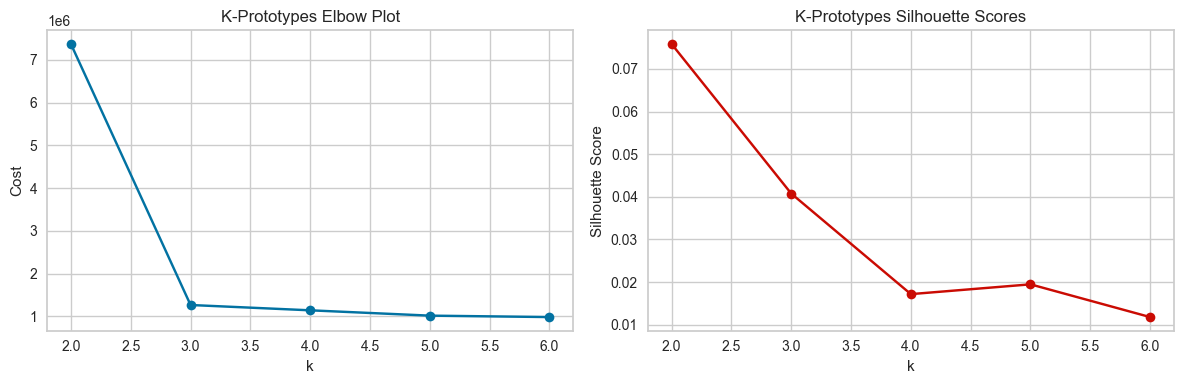

In [75]:
# Find best k using cost (K-Prototypes equivalent of inertia)
costs = []
sil_scores = []

for k in range(2, 7):
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=0, n_jobs=-1, verbose=0)
    labels = kproto.fit_predict(df_kproto.values, categorical=cat_indices)
    costs.append(kproto.cost_)

    # For silhouette, we need a numerical representation
    df_temp = df_kproto.copy()
    for col, mapping in ordinal_maps.items():
        if col in df_temp.columns:
            df_temp[col] = df_temp[col].map(mapping)
    for col in cat_cols:
        if col in df_temp.columns and df_temp[col].dtype == 'object':
            freq = df_temp[col].value_counts(normalize=True)
            df_temp[col] = df_temp[col].map(freq)
    score = silhouette_score(StandardScaler().fit_transform(df_temp), labels)
    sil_scores.append(score)
    print(f"k={k}: cost={kproto.cost_:.0f}, silhouette={score:.4f}")

# Plot elbow
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 7), costs, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Cost')
axes[0].set_title('K-Prototypes Elbow Plot')

axes[1].plot(range(2, 7), sil_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Prototypes Silhouette Scores')

plt.tight_layout()
plt.show()

In [76]:
# Fit with best k (choose based on elbow/silhouette above)
best_k_kp = sil_scores.index(max(sil_scores)) + 2
print(f"Best k for K-Prototypes: {best_k_kp}")

kproto_final = KPrototypes(n_clusters=best_k_kp, init='Cao', random_state=0, n_jobs=-1, verbose=0)
df_full['KProtoCluster'] = kproto_final.fit_predict(df_kproto.values, categorical=cat_indices)

print("\n=== K-Prototypes Cluster Distribution ===")
print(df_full['KProtoCluster'].value_counts(normalize=True).round(3))

# Profile
print("\n=== K-Prototypes Cluster Profiles ===")
for cl in sorted(df_full['KProtoCluster'].unique()):
    subset = df_full[df_full['KProtoCluster'] == cl]
    print(f"\nCluster {cl} (n={len(subset)}, {len(subset)/len(df_full)*100:.1f}%)")
    print(f"  Mean salary:      ${subset['salary_usd'].mean():,.0f}")
    print(f"  Top job_title:    {subset['job_title'].mode().iloc[0]}")
    print(f"  Top exp_level:    {subset['experience_level'].mode().iloc[0]}")
    print(f"  Top emp_type:     {subset['employment_type'].mode().iloc[0]}")
    print(f"  Top location:     {subset['company_location'].mode().iloc[0]}")
    print(f"  Mean benefits:    {subset['benefits_score'].mean():.1f}")
    print(f"  Mean experience:  {subset['years_experience'].mean():.1f} yrs")

Best k for K-Prototypes: 2

=== K-Prototypes Cluster Distribution ===
KProtoCluster
1    0.665
0    0.335
Name: proportion, dtype: float64

=== K-Prototypes Cluster Profiles ===

Cluster 0 (n=4930, 33.5%)
  Mean salary:      $120,437
  Top job_title:    Machine Learning Engineer
  Top exp_level:    MI
  Top emp_type:     CT
  Top location:     Singapore
  Mean benefits:    7.5
  Mean experience:  6.3 yrs

Cluster 1 (n=9771, 66.5%)
  Mean salary:      $120,748
  Top job_title:    Machine Learning Engineer
  Top exp_level:    SE
  Top emp_type:     PT
  Top location:     United Kingdom
  Mean benefits:    7.5
  Mean experience:  6.3 yrs


## Summary: Comparing All Clustering Approaches

| Method | Type | Handles Mixed Data | Forces Clusters | Key Insight |
|--------|------|-------------------|-----------------|-------------|
| PCA + KMeans (original) | Unsupervised | No (requires encoding) | Yes | Dominated by `employment_type_PT` |
| Domain-Driven Tiers | Supervised | N/A | N/A | Interpretable, salary-aligned |
| Residual Clustering | Hybrid | N/A | Yes | Finds over/underpaid groups |
| UMAP + HDBSCAN | Unsupervised | No (requires encoding) | No (allows noise) | Honest about lack of structure |
| Feature Subspace | Unsupervised | No | Yes | Targeted, avoids feature dominance |
| K-Prototypes | Unsupervised | Yes (native) | Yes | No encoding gymnastics |

In [77]:
# Final comparison table
print("=" * 70)
print("FINAL COMPARISON: Mean Salary by Cluster for Each Method")
print("=" * 70)

methods = {
    'SalaryTier': 'Domain-Driven',
    'ResidualCluster': 'Residual',
    'SeniorityCluster': 'Seniority Subspace',
    'CompanyCluster': 'Company Subspace',
    'KProtoCluster': 'K-Prototypes',
}

try:
    df_full['HDB_Cluster'] = hdb_labels
    methods['HDB_Cluster'] = 'UMAP+HDBSCAN'
except:
    pass

for col, name in methods.items():
    if col in df_full.columns:
        print(f"\n--- {name} ---")
        summary = df_full.groupby(col)['salary_usd'].agg(['mean', 'std', 'count'])
        summary['mean'] = summary['mean'].apply(lambda x: f"${x:,.0f}")
        summary['std'] = summary['std'].apply(lambda x: f"${x:,.0f}")
        print(summary.to_string())

FINAL COMPARISON: Mean Salary by Cluster for Each Method

--- Domain-Driven ---
                mean      std  count
SalaryTier                          
Entry        $57,418  $12,991   3676
Mid          $90,369   $8,980   3675
Senior      $128,424  $13,123   3675
Executive   $206,381  $39,490   3675

--- Seniority Subspace ---
                      mean      std  count
SeniorityCluster                          
0                 $159,993  $57,421   7426
1                  $80,478  $25,853   7275

--- Company Subspace ---
                    mean      std  count
CompanyCluster                          
0               $130,426  $61,105   3109
1               $116,923  $55,728   3133
2                $47,595  $19,007    583
3               $130,591  $60,776   3124
4               $110,550  $53,378   3145
5               $135,893  $61,572   1607

--- K-Prototypes ---
                   mean      std  count
KProtoCluster                          
0              $120,437  $59,263   4930
1 

C:\Users\chahi\AppData\Local\Temp\ipykernel_15324\3246536483.py:23: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## Conclusion: Clustering Analysis & Path Forward

### Why Traditional Clustering Failed

After testing 5 different clustering approaches, the evidence consistently shows that **this dataset does not contain natural cluster structure**:

| Method | Best k | Best Silhouette | Verdict |
|--------|--------|----------------|---------|
| PCA + KMeans (original) | 2 | 0.53 | Weak separation; clusters dominated by `employment_type_PT` binary flag |
| Residual Clustering | 3 | 0.53 | Meaningful groups, but clusters salary *deviation*, not role similarity |
| UMAP + HDBSCAN | 9 | 0.87 | High silhouette is misleading — 8 of 9 clusters have identical mean salary (~$121-125k) |
| Feature Subspace | 2 / 6 | 0.32 / 0.42 | Seniority split is useful but too coarse (2 groups); company split lacks actionable insight |
| K-Prototypes | 2 | 0.08 | Essentially random — two clusters with identical salary ($120,437 vs $120,748) |

**Root cause: data homogeneity.** The AI/ML job market in this dataset is continuously distributed across features. Salary is driven by a smooth gradient of experience, location, and company size — not by discrete segments. PCA confirms this: 6 components capture only 56.8% of variance, indicating diffuse spread rather than clustered structure.

### What Worked

Two methods produced **business-meaningful** results, even though they aren't traditional unsupervised clustering:

1. **Method 1 (Domain-Driven Tiers):** 4 balanced salary tiers (Entry/Mid/Senior/Executive) with clear salary separation ($57k → $90k → $128k → $206k). Interpretable and useful for benchmarking, but rule-based — not ML-discovered.

2. **Method 2 (Residual Clustering):** 3 clusters based on regression residuals — Overpaid (+$19,747 avg), Fair (-$4,161 avg), and Underpaid (-$28,613 avg). This reveals **hidden market dynamics** that the regression model alone cannot surface.

### Could Different Feature Engineering Have Helped?

No. The issue is fundamental to the data, not the features:
- Including salary → creates artificial tiers, not role-based segments
- Derived features (salary ratios, location tiers) → redundant with existing encoded features
- Job title groupings → introduces manual bias; job_title was already excluded due to high cardinality
- Different algorithms (Spectral, GMM) → might reach silhouette ~0.55 at best, same fundamental problem
- Fewer/more features → less signal or same diffuse spread

### Path Forward: From Clustering to Classification (Notebook 07)

Since the residual clustering (Method 2) produces the most actionable segments, we will **operationalize it** by training a classification model:

- **Labels:** ResidualCluster (Overpaid / Fair / Underpaid) — already computed from the regression model
- **Features:** Role characteristics (experience, location, company size, job title, etc.)
- **Goal:** Predict which market segment a *new* role falls into, without knowing its actual salary

This gives recruiters a **two-step tool:**
1. **Regression model** → "This role should pay ~$130k"
2. **Classifier** → "The market typically *overpays* roles like this — budget ~$150k to be competitive"

The classifier doesn't replace clustering — it **operationalizes the best clustering insight** into a deployable prediction model.